<a href="https://colab.research.google.com/github/rdityaza/Data-Analytics/blob/main/Tugas_08_18223086_Raditya_Zaki_Athaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Coding: Clustering dengan K-Means dan Hierarchical Clustering

Notebook ini dirancang agar mahasiswa memahami prinsip clustering, tantangan penentuan jumlah kluster, pengaruh scaling, outlier, fitur berkorelasi, serta evaluasi hasil clustering menggunakan K-Means dan Hierarchical Clustering.

## Tujuan Pembelajaran
Setelah menyelesaikan tugas ini, mahasiswa diharapkan mampu:
1. Menjelaskan prinsip dasar clustering dan perbedaan K-Means dengan hierarchical clustering.
2. Melakukan eksplorasi data sebelum clustering.
3. Menerapkan preprocessing, khususnya standardisasi fitur.
4. Menentukan kandidat jumlah kluster menggunakan Elbow Method, Silhouette Score, dan dendrogram.
5. Membandingkan hasil clustering berdasarkan beberapa konfigurasi model.
6. Menafsirkan karakteristik kluster secara kritis, bukan hanya berdasarkan skor numerik.




## 0. Identitas Mahasiswa dan Konfigurasi Pengumpulan

Isi **nama lengkap** dan **NIM** sebelum menjalankan sel berikutnya. Notebook ini menggunakan identitas untuk validasi otomatis,dan pencatatan hasil evaluasi, dan ekspor ringkasan nilai ke Excel/Google Sheet.

In [ ]:
# ==========================================================
# IDENTITAS MAHASISWA - WAJIB DIISI
# ==========================================================

NAMA = "Raditya Zaki Athaya"
NIM = "18223086"
KELAS = "01"  # contoh: 01

# Konfigurasi pengumpulan hasil otomatis
AUTO_EXPORT_EXCEL = True
AUTO_UPLOAD_GOOGLE_SHEET = False  # ubah menjadi True jika dosen menyediakan akses Google Sheet

# Google Sheet configuration - diisi hanya jika AUTO_UPLOAD_GOOGLE_SHEET = True
GOOGLE_SHEET_ID = "ISI_ID_GOOGLE_SHEET"
GOOGLE_WORKSHEET_NAME = "Clustering_Submission"
SERVICE_ACCOUNT_JSON = "service_account.json"  # letakkan file kredensial di direktori kerja notebook

print("Nama :", NAMA)
print("NIM  :", NIM)
print("Kelas:", KELAS)

Nama : Raditya Zaki Athaya
NIM  : 18223086
Kelas: 01


In [ ]:
# ==========================================================
# VALIDASI IDENTITAS MAHASISWA
# ==========================================================
import re
import hashlib
from datetime import datetime

def validate_identity(nama: str, nim: str, kelas: str = ""):
    errors = []
    if not isinstance(nama, str) or nama.strip() == "" or nama.strip() == "ISI_NAMA_LENGKAP":
        errors.append("Nama belum diisi dengan benar.")
    if not isinstance(nim, str) or nim.strip() == "" or nim.strip() == "ISI_NIM":
        errors.append("NIM belum diisi dengan benar.")
    elif not re.fullmatch(r"\d{6,20}", nim.strip()):
        errors.append("NIM harus berupa angka dengan panjang 6-20 digit.")
    if not isinstance(kelas, str) or kelas.strip() == "" or kelas.strip() == "ISI_KELAS":
        errors.append("Kelas belum diisi.")
    return errors

identity_errors = validate_identity(NAMA, NIM, KELAS)
if identity_errors:
    for err in identity_errors:
        print("❌", err)
    raise ValueError("Identitas belum valid. Lengkapi NAMA, NIM, dan KELAS sebelum melanjutkan.")
else:
    STUDENT_FINGERPRINT = hashlib.sha256(f"{NAMA.strip().lower()}|{NIM.strip()}|{KELAS.strip().lower()}".encode()).hexdigest()[:16]
    SUBMISSION_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print("✅ Identitas valid")
    print("Submission timestamp:", SUBMISSION_TIMESTAMP)
    print("Student fingerprint:", STUDENT_FINGERPRINT)

✅ Identitas valid
Submission timestamp: 2026-05-09 09:42:15
Student fingerprint: c335037307df40e3


## 0.1 Fungsi Auto-Check dan Ekspor Hasil

Sel berikut digunakan untuk mencatat status pengerjaan, menghasilkan file Excel ringkasan, dan mengunggah hasil ke Google Sheet jika konfigurasi dosen tersedia. Mahasiswa cukup menjalankan sel ini tanpa mengubah fungsi.

In [ ]:
# ==============================================================
# FUNGSI BANTU AUTO-CHECK, EXCEL EXPORT, DAN GOOGLE SHEET UPLOAD
# ==============================================================
import os
import json
import math
import pandas as pd
from datetime import datetime

AUTOCHECK_RESULTS = {}

def _safe_get(name, default=None):
    return globals().get(name, default)

def record_check(name, passed, detail="", score=0, max_score=1):
    AUTOCHECK_RESULTS[name] = {
        "passed": bool(passed),
        "detail": str(detail),
        "score": float(score),
        "max_score": float(max_score)
    }
    icon = "✅" if passed else "❌"
    print(f"{icon} {name}: {detail}")
    return passed

def export_autocheck_to_excel(filename=None):
    if filename is None:
        filename = f"hasil_autocheck_clustering_{NIM}.xlsx"
    rows = []
    for key, value in AUTOCHECK_RESULTS.items():
        rows.append({
            "Nama": NAMA,
            "NIM": NIM,
            "Kelas": KELAS,
            "Fingerprint": STUDENT_FINGERPRINT,
            "Timestamp": SUBMISSION_TIMESTAMP,
            "Check": key,
            "Passed": value.get("passed", False),
            "Detail": value.get("detail", ""),
            "Score": value.get("score", 0),
            "Max Score": value.get("max_score", 1)
        })
    df = pd.DataFrame(rows)
    summary = pd.DataFrame([{
        "Nama": NAMA,
        "NIM": NIM,
        "Kelas": KELAS,
        "Fingerprint": STUDENT_FINGERPRINT,
        "Timestamp": SUBMISSION_TIMESTAMP,
        "Total Score": df["Score"].sum() if not df.empty else 0,
        "Max Score": df["Max Score"].sum() if not df.empty else 0,
        "Auto Score (%)": round((df["Score"].sum() / df["Max Score"].sum()) * 100, 2) if (not df.empty and df["Max Score"].sum() > 0) else 0
    }])
    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        summary.to_excel(writer, sheet_name="Summary", index=False)
        df.to_excel(writer, sheet_name="Detail_Check", index=False)
    print(f"✅ Hasil auto-check diekspor ke: {filename}")
    return filename

def upload_autocheck_to_google_sheet():
    """
    Mengunggah ringkasan hasil ke Google Sheet.
    Prasyarat:
    1. Dosen menyediakan GOOGLE_SHEET_ID.
    2. File service_account.json tersedia atau autentikasi Google Colab dikonfigurasi.
    3. Library gspread tersedia: pip install gspread google-auth
    """
    if not AUTO_UPLOAD_GOOGLE_SHEET:
        print("ℹ️ AUTO_UPLOAD_GOOGLE_SHEET = False. Upload Google Sheet dilewati.")
        return False
    if GOOGLE_SHEET_ID == "ISI_ID_GOOGLE_SHEET":
        print("❌ GOOGLE_SHEET_ID belum diisi.")
        return False
    try:
        import gspread
        from google.oauth2.service_account import Credentials
        scopes = ["https://www.googleapis.com/auth/spreadsheets"]
        credentials = Credentials.from_service_account_file(SERVICE_ACCOUNT_JSON, scopes=scopes)
        client = gspread.authorize(credentials)
        spreadsheet = client.open_by_key(GOOGLE_SHEET_ID)
        try:
            worksheet = spreadsheet.worksheet(GOOGLE_WORKSHEET_NAME)
        except Exception:
            worksheet = spreadsheet.add_worksheet(title=GOOGLE_WORKSHEET_NAME, rows=1000, cols=20)
            worksheet.append_row(["Timestamp", "Nama", "NIM", "Kelas", "Fingerprint", "Total Score", "Max Score", "Auto Score (%)"])
        total_score = sum(v.get("score", 0) for v in AUTOCHECK_RESULTS.values())
        max_score = sum(v.get("max_score", 0) for v in AUTOCHECK_RESULTS.values())
        pct = round((total_score / max_score) * 100, 2) if max_score else 0
        worksheet.append_row([SUBMISSION_TIMESTAMP, NAMA, NIM, KELAS, STUDENT_FINGERPRINT, total_score, max_score, pct])
        print("✅ Hasil berhasil diunggah ke Google Sheet.")
        return True
    except Exception as e:
        print("❌ Upload Google Sheet gagal:", str(e))
        print("Pastikan gspread terinstal dan service_account.json memiliki akses editor ke Google Sheet.")
        return False

## 1. Import Library
Jalankan sel berikut untuk memuat seluruh library yang dibutuhkan.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

## 2. Membuat Dataset Sintetis

Dataset dibuat agar memiliki karakteristik yang realistis dan tidak terlalu mudah dipisahkan:
- sebagian kluster saling tumpang tindih;
- terdapat fitur dengan skala berbeda;
- terdapat outlier ringan;
- beberapa fitur berkorelasi;
- terdapat lebih dari satu jumlah kluster yang tampak masuk akal.

Dataset ini tidak memiliki label kelas asli untuk proses clustering. Label `hidden_group` hanya digunakan dosen untuk memahami struktur data dan tidak boleh digunakan sebagai fitur clustering.

In [ ]:
# Membuat data dasar dengan struktur kluster yang tidak terlalu jelas
X_base, hidden_group = make_blobs(
    n_samples=420,
    centers=[[-1.5, 0], [1.2, 0.4], [0.2, 2.2], [4.0, 3.2]],
    cluster_std=[1.1, 1.2, 1.0, 1.4],
    random_state=42
)

# Membuat fitur turunan dengan korelasi dan skala berbeda
f1 = X_base[:, 0]
f2 = X_base[:, 1]
f3 = 2.8 * f1 + np.random.normal(0, 1.0, size=len(f1))          # berkorelasi dengan f1
f4 = 80 + 18 * f2 + np.random.normal(0, 8.0, size=len(f2))       # skala lebih besar
f5 = np.random.normal(0, 1.0, size=len(f1)) + 0.4 * f1           # noise + korelasi ringan

X = np.column_stack([f1, f2, f3, f4, f5])

# Menambahkan outlier ringan
outliers = np.array([
    [6.5, -2.5, 17.0, 35.0, 3.2],
    [-5.5, 4.5, -14.0, 160.0, -2.5],
    [7.2, 6.0, 20.0, 190.0, 1.8],
    [-4.8, -3.5, -13.0, 20.0, -3.0]
])

X_all = np.vstack([X, outliers])
hidden_group_all = np.concatenate([hidden_group, [-1, -1, -1, -1]])

df = pd.DataFrame(X_all, columns=['fitur_1', 'fitur_2', 'fitur_3_korelasi', 'fitur_4_skala_besar', 'fitur_5_noise'])
df['hidden_group'] = hidden_group_all

df.head()

,fitur_1,fitur_2,fitur_3_korelasi,fitur_4_skala_besar,fitur_5_noise,hidden_group
0,0.845376,3.568632,2.863767,160.721351,0.288687,2
1,0.224359,3.123987,0.489940,150.274496,0.764563,3
2,1.237540,1.689984,4.112800,108.427992,-0.627706,2
3,-0.440286,0.454059,0.290228,95.945630,0.206295,0
4,3.103220,-1.085379,8.454863,65.626193,1.407740,1


In [ ]:
print('Ukuran dataset:', df.shape)
df.describe().T

Ukuran dataset: (424, 6)


,count,mean,std,min,25%,50%,75%,max
fitur_1,424.0,0.963059,2.383153,-5.500000,-0.818136,0.634218,2.636771,7.602704
fitur_2,424.0,1.452582,1.762011,-3.500000,0.206830,1.294060,2.672414,6.885335
fitur_3_korelasi,424.0,2.717281,6.648451,-14.000000,-2.385151,2.011969,7.247670,22.058076
fitur_4_skala_besar,424.0,105.954794,32.895976,20.000000,82.640557,102.645442,127.978074,204.704994
fitur_5_noise,424.0,0.499671,1.391684,-3.570598,-0.474327,0.503875,1.507141,4.559821
hidden_group,424.0,1.476415,1.140035,-1.000000,0.000000,1.000000,2.000000,3.000000


## 3. Eksplorasi Data Awal

Sebelum menjalankan clustering, amati distribusi fitur, skala data, korelasi antarfitur, dan indikasi outlier.

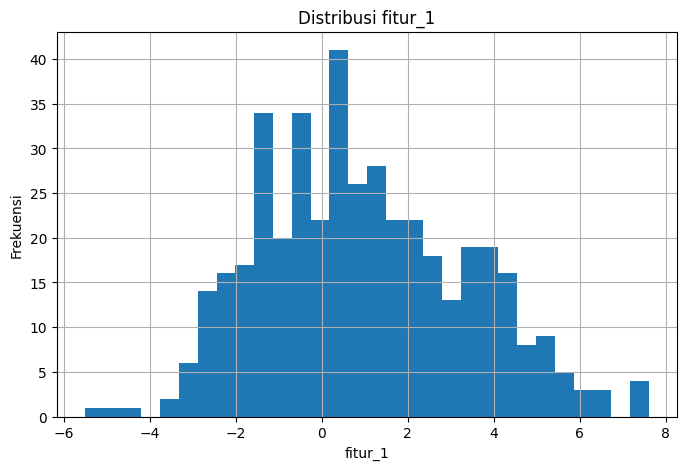

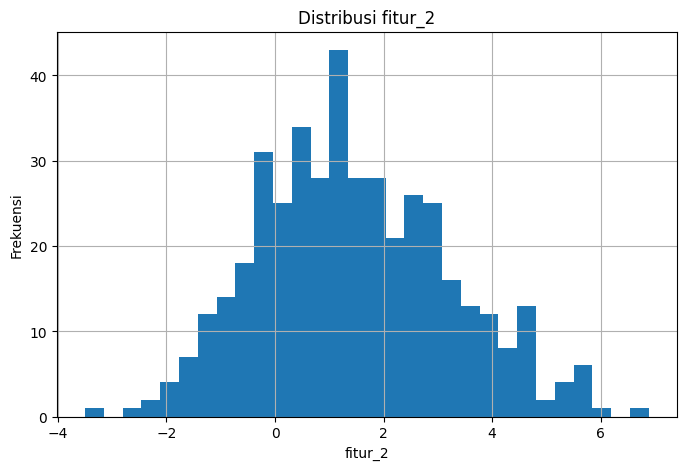

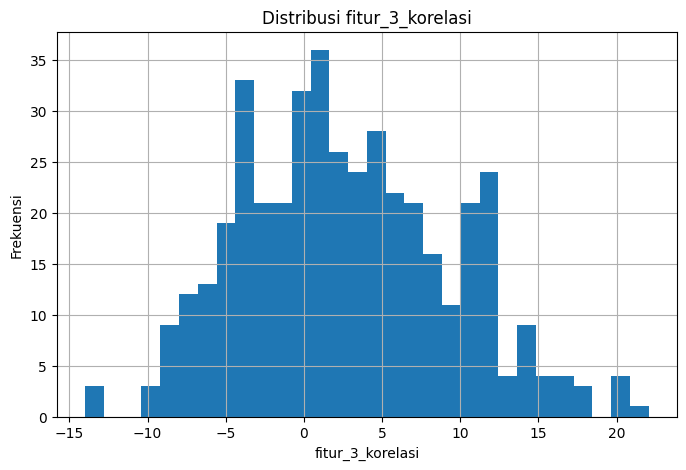

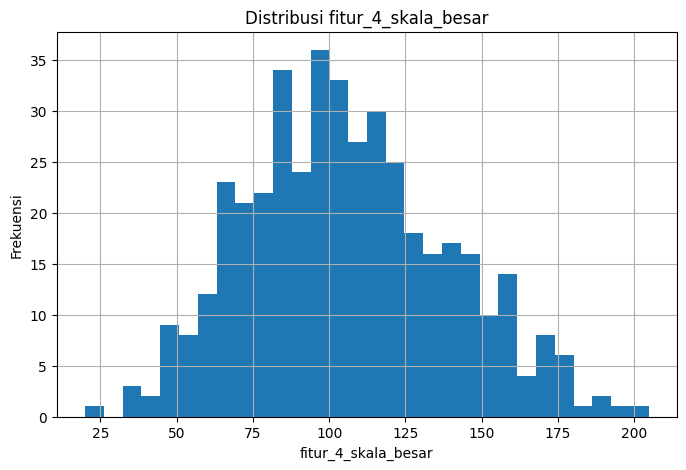

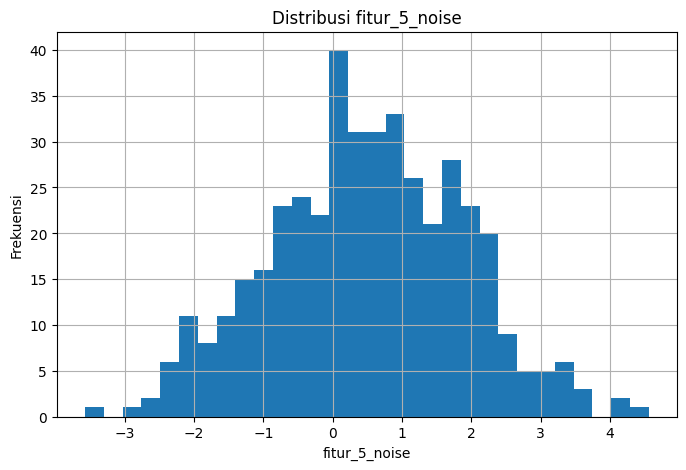

In [ ]:
# Visualisasi distribusi setiap fitur
feature_cols = ['fitur_1', 'fitur_2', 'fitur_3_korelasi', 'fitur_4_skala_besar', 'fitur_5_noise']

for col in feature_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

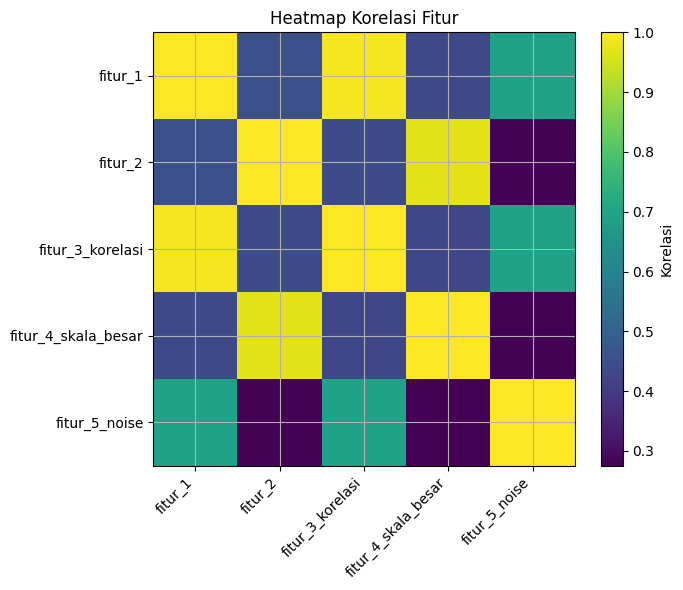

,fitur_1,fitur_2,fitur_3_korelasi,fitur_4_skala_besar,fitur_5_noise
fitur_1,1.000000,0.451836,0.989702,0.436332,0.693802
fitur_2,0.451836,1.000000,0.444686,0.969963,0.279302
fitur_3_korelasi,0.989702,0.444686,1.000000,0.429155,0.691686
fitur_4_skala_besar,0.436332,0.969963,0.429155,1.000000,0.275142
fitur_5_noise,0.693802,0.279302,0.691686,0.275142,1.000000


In [ ]:
# Korelasi antar fitur
corr = df[feature_cols].corr()
plt.figure(figsize=(7, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Korelasi')
plt.xticks(range(len(feature_cols)), feature_cols, rotation=45, ha='right')
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.show()

corr

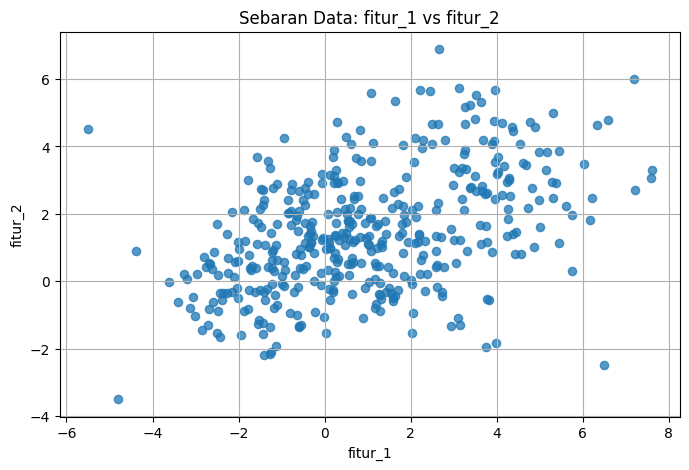

In [ ]:
# Visualisasi dua fitur awal untuk melihat struktur kasar data
plt.figure()
plt.scatter(df['fitur_1'], df['fitur_2'], s=35, alpha=0.75)
plt.title('Sebaran Data: fitur_1 vs fitur_2')
plt.xlabel('fitur_1')
plt.ylabel('fitur_2')
plt.show()

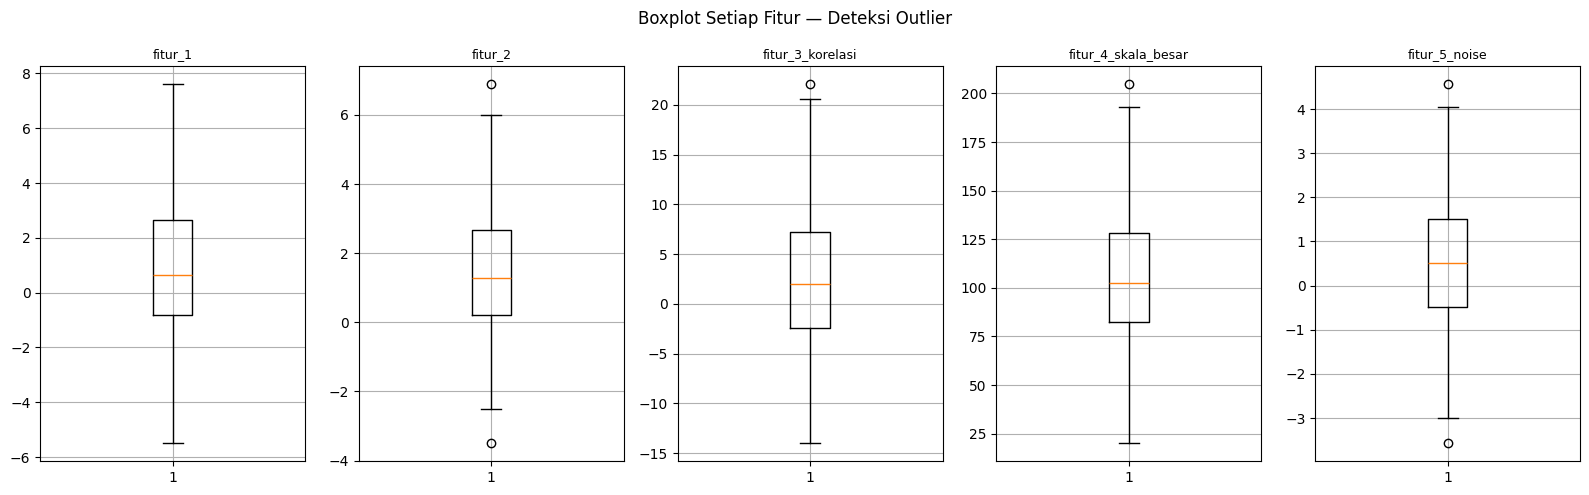

In [ ]:
# Boxplot untuk deteksi outlier per fitur
fig, axes = plt.subplots(1, len(feature_cols), figsize=(16, 5))
for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
fig.suptitle('Boxplot Setiap Fitur — Deteksi Outlier', fontsize=12)
plt.tight_layout()
plt.show()

### Tugas Mahasiswa 1 — Analisis Eksplorasi Data
Jawab pertanyaan berikut:
1. Fitur mana yang memiliki skala paling berbeda dibanding fitur lainnya? Mengapa hal ini penting untuk clustering?
2. Fitur mana yang tampak berkorelasi kuat? Apa dampaknya terhadap interpretasi kluster?
3. Apakah terdapat indikasi outlier? Jelaskan berdasarkan visualisasi atau statistik deskriptif.
4. Berdasarkan scatter plot awal, apakah jumlah kluster terlihat jelas? Jelaskan.

1. fitur_4_skala_besar (mean ≈ 105.95, std ≈ 32.90) jauh lebih besar dibanding fitur lain yang memiliki mean ~0–3 dan std ~1–7. Ini penting karena K-Means berbasis jarak Euclidean, fitur berskala besar mendominasi perhitungan jarak sehingga kluster hampir sepenuhnya ditentukan oleh fitur tersebut dan fitur lain menjadi tidak relevan.

2. fitur_1 & fitur_3_korelasi (r = 0.989) dan fitur_2 & fitur_4_skala_besar (r = 0.969). Dampaknya, pasangan fitur ini membawa informasi redundan yang bobotnya terhitung dua kali dalam perhitungan jarak, sehingga dimensi tersebut mendominasi pembentukan kluster secara tidak proporsional.

3. Ya, ada indikasi outlier. Boxplot menunjukkan titik-titik ekstrem di semua fitur, paling jelas pada fitur_4_skala_besar (nilai hingga ~200, jauh dari IQR). Statistik deskriptif juga mengkonfirmasi: fitur_1 (min = -5.5 vs mean = 0.96), fitur_4 (min = 20, max = 204 vs mean = 105.9).

4. Kluster tidak terlalu jelas. Scatter fitur_1 vs fitur_2 menunjukkan sebaran yang tumpang tindih tanpa batas tegas. Ada indikasi 2–4 kelompok, tetapi tidak bisa dipastikan secara visual karena densitas data yang bercampur.

## 4. Preprocessing: Standardisasi Fitur

K-Means dan hierarchical clustering berbasis jarak sangat sensitif terhadap skala fitur. Oleh karena itu, data perlu distandardisasi.

In [ ]:
X_raw = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
fitur_1,424.0,1.675808e-17,1.001181,-2.715182,-0.748294,-0.138149,0.703140,2.789367
fitur_2,424.0,-1.026433e-16,1.001181,-2.814076,-0.707841,-0.090073,0.693113,3.086911
fitur_3_korelasi,424.0,-2.094760e-17,1.001181,-2.517433,-0.768368,-0.106212,0.682225,2.912505
fitur_4_skala_besar,424.0,-4.357102e-16,1.001181,-2.616014,-0.709563,-0.100719,0.670273,3.005439
fitur_5_noise,424.0,1.256856e-17,1.001181,-2.928162,-0.700696,0.003024,0.724777,2.920883


Explained variance ratio: [0.65767898 0.25760445]


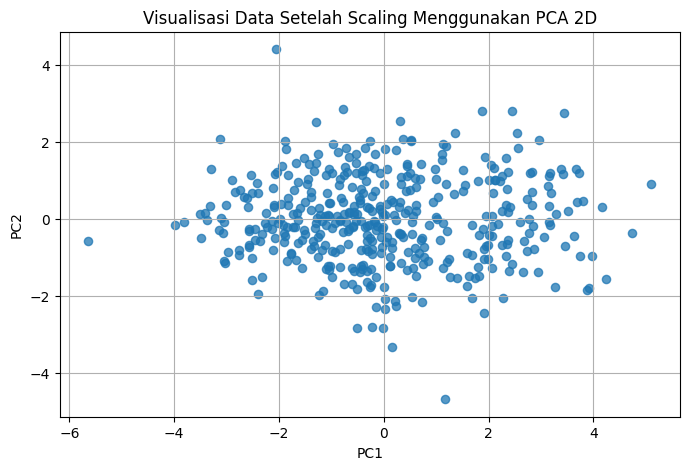

In [ ]:
# Visualisasi PCA 2D setelah scaling untuk membantu analisis struktur data
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print('Explained variance ratio:', pca.explained_variance_ratio_)

plt.figure()
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=35, alpha=0.75)
plt.title('Visualisasi Data Setelah Scaling Menggunakan PCA 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## 5. K-Means: Menentukan Jumlah Kluster

Gunakan beberapa metrik untuk mengevaluasi jumlah kluster. Perhatikan bahwa tidak selalu ada satu jawaban benar. Mahasiswa harus memberikan argumentasi berbasis bukti.

In [ ]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []
db_scores = []
ch_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

eval_kmeans = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertias,
    'silhouette': silhouette_scores,
    'davies_bouldin': db_scores,
    'calinski_harabasz': ch_scores
})

eval_kmeans

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,1196.168893,0.378004,1.014946,325.921138
1,3,924.348714,0.285673,1.227793,272.283168
2,4,715.867063,0.307394,1.024268,274.602117
3,5,625.529161,0.285194,1.100113,250.261427
4,6,559.256963,0.271945,1.151718,233.306202
5,7,505.869540,0.249955,1.153285,221.760865
6,8,464.069917,0.251844,1.142025,212.057614
7,9,432.662021,0.244293,1.139138,202.307236
8,10,405.320999,0.239845,1.169566,194.599426


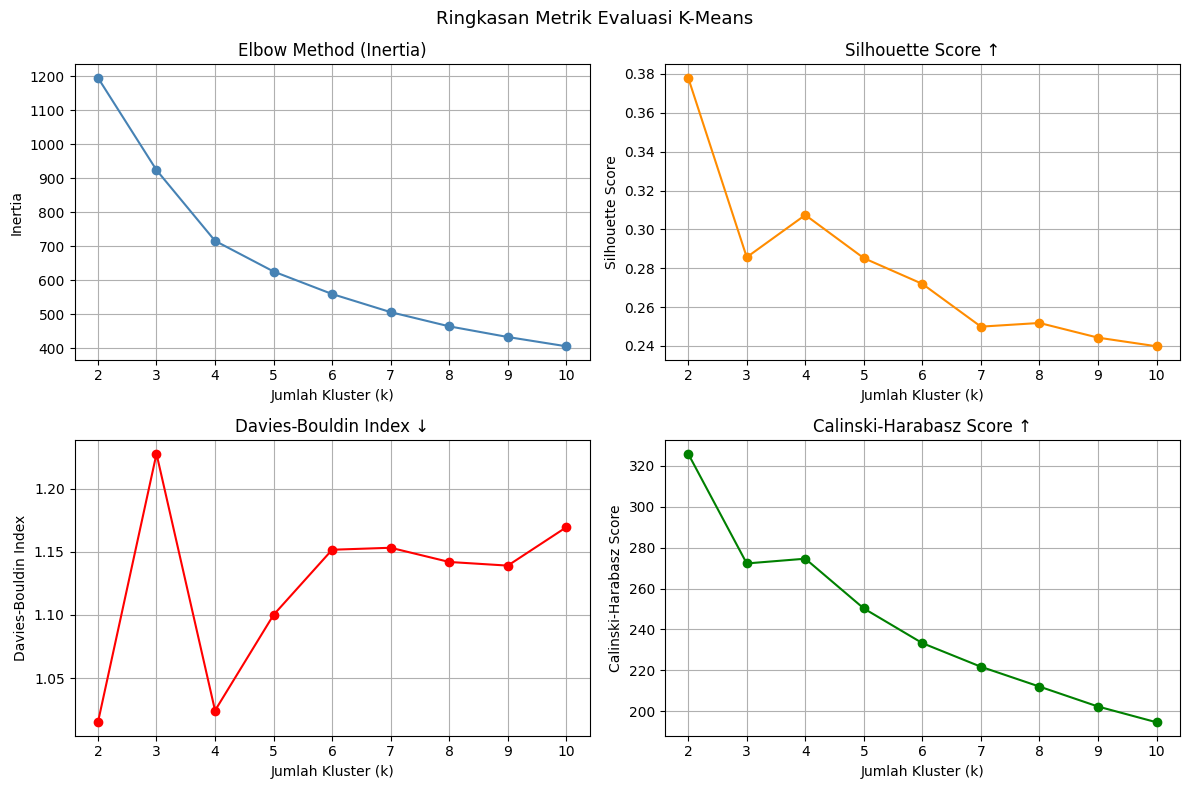

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(eval_kmeans['k'], eval_kmeans['inertia'], marker='o', color='steelblue')
axes[0, 0].set_title('Elbow Method (Inertia)')
axes[0, 0].set_xlabel('Jumlah Kluster (k)')
axes[0, 0].set_ylabel('Inertia')

axes[0, 1].plot(eval_kmeans['k'], eval_kmeans['silhouette'], marker='o', color='darkorange')
axes[0, 1].set_title('Silhouette Score ↑')
axes[0, 1].set_xlabel('Jumlah Kluster (k)')
axes[0, 1].set_ylabel('Silhouette Score')

axes[1, 0].plot(eval_kmeans['k'], eval_kmeans['davies_bouldin'], marker='o', color='red')
axes[1, 0].set_title('Davies-Bouldin Index ↓')
axes[1, 0].set_xlabel('Jumlah Kluster (k)')
axes[1, 0].set_ylabel('Davies-Bouldin Index')

axes[1, 1].plot(eval_kmeans['k'], eval_kmeans['calinski_harabasz'], marker='o', color='green')
axes[1, 1].set_title('Calinski-Harabasz Score ↑')
axes[1, 1].set_xlabel('Jumlah Kluster (k)')
axes[1, 1].set_ylabel('Calinski-Harabasz Score')

plt.suptitle('Ringkasan Metrik Evaluasi K-Means', fontsize=13)
plt.tight_layout()
plt.show()

### Tugas Mahasiswa 2 — Pemilihan Jumlah Kluster K-Means
Jawab pertanyaan berikut:
1. Berdasarkan Elbow Method, berapa kandidat jumlah kluster yang masuk akal?
2. Berdasarkan Silhouette Score, jumlah kluster mana yang tampak paling baik?
3. Apakah semua metrik memberikan rekomendasi jumlah kluster yang sama? Jika tidak, bagaimana Anda mengambil keputusan?
4. Pilih satu nilai `k` utama dan satu nilai `k` pembanding. Jelaskan alasan pemilihan tersebut.

1. **Kandidat dari Elbow Method**: Penurunan inertia paling tajam terjadi dari k=2→3→4 (1196→924→715). Setelah k=4 laju melambat signifikan → kandidat elbow: **k=3** atau **k=4**.

2. **Silhouette Score terbaik**: k=2 tertinggi (0.378), diikuti k=4 (0.307). Secara metrik ini, k=2 tampak terbaik.

3. **Konsistensi antar metrik**: Tidak sepenuhnya konsisten. Silhouette dan CH memilih k=2; Elbow mengarah ke k=3–4; DB menunjukkan k=2 dan k=4 hampir sama (1.015 vs 1.024). Keputusan diambil dengan mempertimbangkan bahwa k=2 terlalu kasar dan tidak mengungkap struktur yang lebih kaya. k=4 dipilih karena konsisten di posisi kedua terbaik di semua metrik sekaligus menghasilkan granularitas yang lebih interpretatif.

4. **Pilihan k dan alasan**:
*   k_utama = 4: performa metrik seimbang (silhouette=0.307, DB=1.024, CH=274.6) dan sesuai struktur data.
*   k_pembanding = 3: merupakan kandidat elbow alternatif, berguna untuk menguji apakah pemisahan 4 kluster benar-benar lebih informatif dibanding 3.




## 6. K-Means: Pelatihan Model dan Visualisasi Hasil

Ubah nilai `k_utama` dan `k_pembanding` sesuai hasil analisis Anda.

In [ ]:
# Silakan ubah berdasarkan hasil analisis Anda
k_utama = 4
k_pembanding = 3

kmeans_utama = KMeans(n_clusters=k_utama, random_state=42, n_init=20)
kmeans_pembanding = KMeans(n_clusters=k_pembanding, random_state=42, n_init=20)

df['cluster_kmeans_utama'] = kmeans_utama.fit_predict(X_scaled)
df['cluster_kmeans_pembanding'] = kmeans_pembanding.fit_predict(X_scaled)

print('Distribusi cluster K-Means utama:')
print(df['cluster_kmeans_utama'].value_counts().sort_index())

print('Distribusi cluster K-Means pembanding:')
print(df['cluster_kmeans_pembanding'].value_counts().sort_index())

Distribusi cluster K-Means utama:
cluster_kmeans_utama
0    114
1     93
2    106
3    111
Name: count, dtype: int64
Distribusi cluster K-Means pembanding:
cluster_kmeans_pembanding
0    186
1    106
2    132
Name: count, dtype: int64


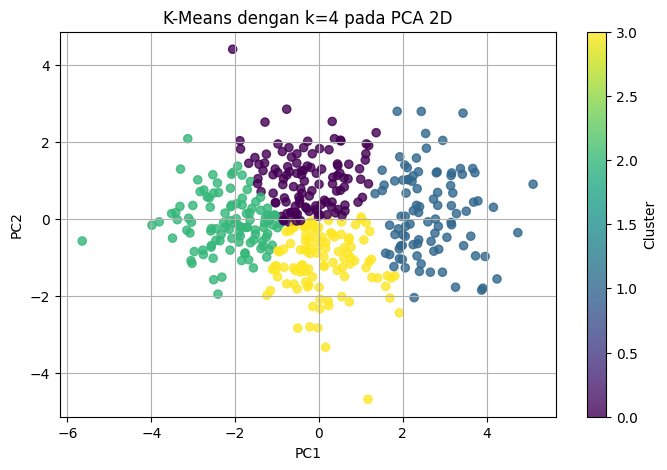

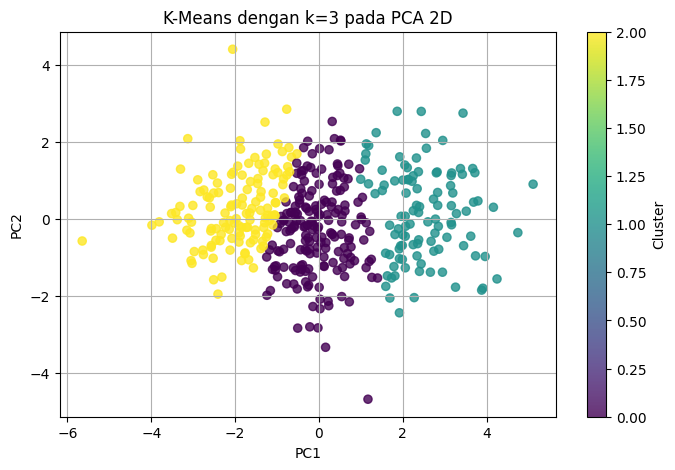

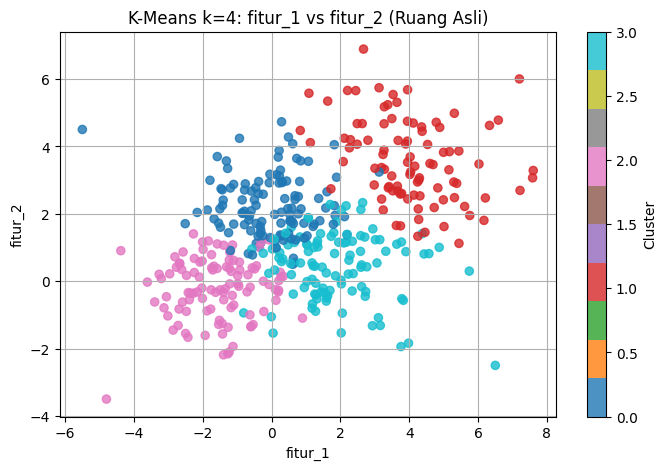

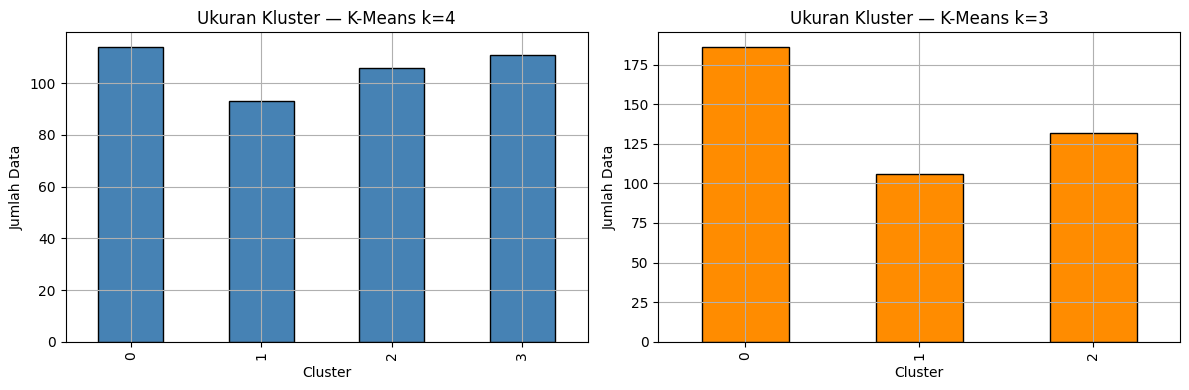

In [ ]:
def plot_cluster_pca(labels, title):
    plt.figure()
    scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=labels, s=35, alpha=0.8)
    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.colorbar(scatter, label='Cluster')
    plt.show()

plot_cluster_pca(df['cluster_kmeans_utama'], f'K-Means dengan k={k_utama} pada PCA 2D')
plot_cluster_pca(df['cluster_kmeans_pembanding'], f'K-Means dengan k={k_pembanding} pada PCA 2D')

# Scatter plot fitur asli (bukan PCA) dengan warna kluster
plt.figure()
scatter = plt.scatter(df['fitur_1'], df['fitur_2'],
                      c=df['cluster_kmeans_utama'], s=35, alpha=0.8, cmap='tab10')
plt.title(f'K-Means k={k_utama}: fitur_1 vs fitur_2 (Ruang Asli)')
plt.xlabel('fitur_1')
plt.ylabel('fitur_2')
plt.colorbar(scatter, label='Cluster')
plt.show()

# Bar chart distribusi ukuran kluster
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['cluster_kmeans_utama'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title(f'Ukuran Kluster — K-Means k={k_utama}')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Jumlah Data')

df['cluster_kmeans_pembanding'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title(f'Ukuran Kluster — K-Means k={k_pembanding}')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Jumlah Data')

plt.tight_layout()
plt.show()

In [ ]:
# Profil kluster berdasarkan rata-rata fitur asli
profile_kmeans = df.groupby('cluster_kmeans_utama')[feature_cols].mean()
profile_kmeans

,fitur_1,fitur_2,fitur_3_korelasi,fitur_4_skala_besar,fitur_5_noise
cluster_kmeans_utama,,,,,
0,-0.043322,2.244294,-0.065013,121.301877,-0.290548
1,4.040444,3.576001,11.178499,144.665449,1.824796
2,-1.572852,-0.207040,-4.366428,75.139135,-0.562575
3,1.839970,0.445257,5.250266,87.187240,1.215403


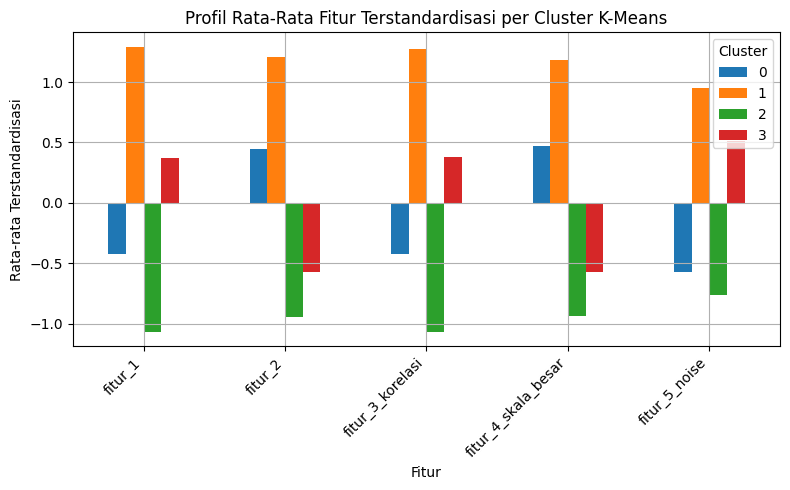

In [ ]:
# Visualisasi profil kluster dalam data yang sudah distandardisasi
profile_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
profile_scaled['cluster'] = df['cluster_kmeans_utama']
profile_scaled_mean = profile_scaled.groupby('cluster')[feature_cols].mean()

profile_scaled_mean.T.plot(kind='bar')
plt.title('Profil Rata-Rata Fitur Terstandardisasi per Cluster K-Means')
plt.xlabel('Fitur')
plt.ylabel('Rata-rata Terstandardisasi')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

### Tugas Mahasiswa 3 — Interpretasi K-Means
Jawab pertanyaan berikut:
1. Jelaskan karakteristik setiap kluster berdasarkan profil fitur.
2. Apakah ada kluster yang sangat kecil atau tampak didominasi outlier? Jelaskan.
3. Bandingkan hasil `k_utama` dan `k_pembanding`. Mana yang lebih mudah dijelaskan secara substantif?
4. Mengapa visualisasi PCA 2D tidak boleh menjadi satu-satunya dasar penentuan kualitas kluster?

1. Berdasarkan rata-rata fitur per kluster (`profile_kmeans`):

| Cluster | fitur_1 | fitur_2 | fitur_3_korelasi | fitur_4_skala_besar | fitur_5_noise | Karakteristik |
|---------|--------:|--------:|-----------------:|--------------------:|--------------:|---------------|
| 0       | -0.04   | 2.24    | -0.06            | 121.30              | -0.29        | f2 & f4 tinggi, f1 & f3 rendah — *kelompok nilai menengah-atas (dominan f2)* |
| 1       |  4.04   | 3.58    | 11.18            | 144.66              | 1.82         | semua fitur bernilai tinggi — *kelompok ekstrem tinggi* |
| 2       | -1.57   | -0.21   | -4.37            | 75.13               | -0.56        | semua fitur bernilai rendah — *kelompok rendah* |
| 3       |  1.84   | 0.45    | 5.25             | 87.18               | 1.21         | semua fitur bernilai sedang — *kelompok menengah* |


> Kluster 2 dan 3 paling mudah dibedakan (nilai rendah vs sedang di semua fitur).
> Kluster 0 dan 1 serupa di f2 & f4 (keduanya tinggi), namun sangat berbeda di f1 & f3,
> menunjukkan pemisahan yang ditangkap dari dimensi selain f2.


2. **Kluster kecil atau outlier**: Distribusi cukup merata (93–114 per kluster). Kluster 1 (93 data) adalah yang terkecil dan memiliki nilai fitur paling ekstrem, kemungkinan menyerap sebagian outlier yang ditambahkan secara eksplisit.

3. **Perbandingan k_utama vs k_pembanding**: k=4 lebih mudah diinterpretasi karena setiap kluster memiliki profil yang cukup berbeda dan ukuran seimbang. Pada k=3, dua kelompok yang sebenarnya berbeda (kluster 0 dan 3 di k=4) tergabung menjadi satu, menghasilkan profil kluster yang lebih kabur.

4. **Keterbatasan visualisasi PCA 2D**: PCA memproyeksikan 5 dimensi ke 2 dimensi sehingga sebagian varians hilang. Meskipun pada kasus ini PC1 dan PC2 menangkap 91.5% varians (0.658 + 0.258), sebesar 8.5% informasi tetap hilang dan bisa jadi justru mengandung sinyal pemisah kluster. Kluster yang tampak tumpang tindih di PCA bisa saja terpisah baik di dimensi aslinya. Kualitas kluster harus dinilai dari metrik berbasis jarak di ruang dimensi penuh, bukan dari penampakan visual 2D.





## 7. Hierarchical Clustering: Dendrogram

Dendrogram membantu melihat struktur penggabungan data. Karena dendrogram dengan seluruh data dapat terlalu padat, visualisasi berikut menggunakan sampel data.

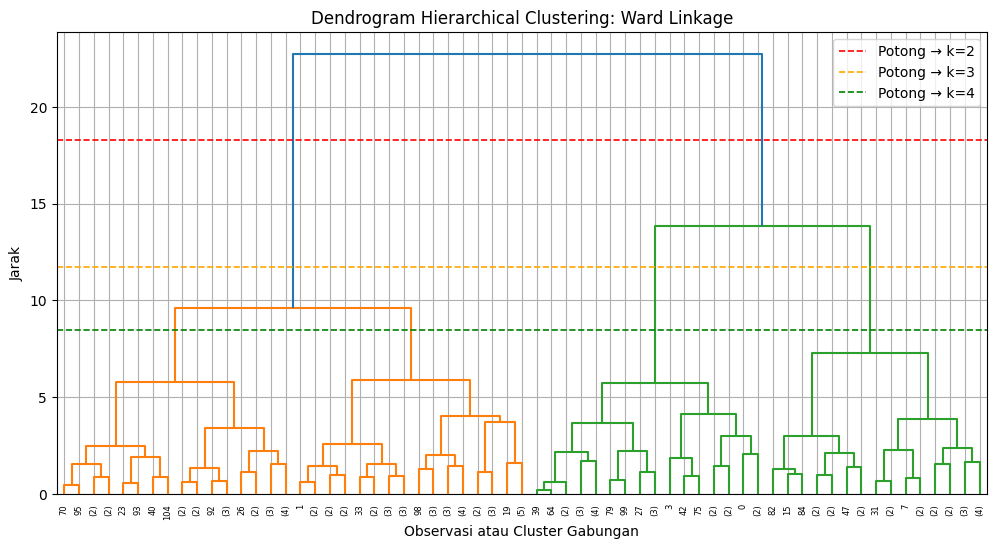

In [ ]:
# Ambil sampel agar dendrogram terbaca
sample_size = 120
sample_idx = np.random.choice(np.arange(X_scaled.shape[0]), size=sample_size, replace=False)
X_sample = X_scaled[sample_idx]

Z_ward = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z_ward, truncate_mode='level', p=5)
plt.title('Dendrogram Hierarchical Clustering: Ward Linkage')
plt.xlabel('Observasi atau Cluster Gabungan')
plt.ylabel('Jarak')

# Garis potong untuk membantu membaca kandidat jumlah kluster
merge_distances = sorted(Z_ward[:, 2], reverse=True)
plt.axhline(y=(merge_distances[0] + merge_distances[1]) / 2, color='red',    linestyle='--', linewidth=1.2, label='Potong → k=2')
plt.axhline(y=(merge_distances[1] + merge_distances[2]) / 2, color='orange', linestyle='--', linewidth=1.2, label='Potong → k=3')
plt.axhline(y=(merge_distances[2] + merge_distances[3]) / 2, color='green',  linestyle='--', linewidth=1.2, label='Potong → k=4')
plt.legend()

plt.show()

### Tugas Mahasiswa 4 — Analisis Dendrogram
Jawab pertanyaan berikut:
1. Berdasarkan dendrogram, berapa kandidat jumlah kluster yang masuk akal?
2. Apakah hasil dendrogram mendukung hasil K-Means? Jelaskan.
3. Apa keterbatasan penggunaan dendrogram pada dataset berukuran besar atau memiliki outlier?

1. **Kandidat jumlah kluster dari dendrogram**: Garis potong menunjukkan kandidat yang masuk akal adalah k=2, 3, dan 4. Gap vertikal terpanjang sebelum penggabungan besar mengisyaratkan k=2 atau k=3, namun k=4 juga terbaca jelas dari garis potong hijau.

2. **Kesesuaian dengan K-Means**: Ya, secara umum mendukung. Dendrogram memperlihatkan 3–4 kelompok besar yang terbentuk sebelum semua data bergabung, konsisten dengan pilihan k=4 di K-Means.

3. **Keterbatasan dendrogram**: Pada dataset besar, dendrogram menjadi sangat padat dan tidak terbaca (diatasi dengan sampling, yang berisiko tidak representatif). Pada data dengan outlier, outlier muncul sebagai cabang tunggal panjang yang menyulitkan penentuan cut threshold yang tepat dan dapat mengaburkan struktur kluster utama.

## 8. Hierarchical Clustering: Perbandingan Linkage

Bandingkan beberapa metode linkage untuk melihat pengaruh strategi penggabungan kluster.

In [ ]:
linkage_methods = ['ward', 'complete', 'average', 'single']
n_clusters_h = 4

hier_results = []

for method in linkage_methods:
    model = AgglomerativeClustering(n_clusters=n_clusters_h, linkage=method)
    labels = model.fit_predict(X_scaled)
    hier_results.append({
        'linkage': method,
        'n_clusters': n_clusters_h,
        'silhouette': silhouette_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels)
    })
    df[f'cluster_hier_{method}'] = labels

hier_eval = pd.DataFrame(hier_results)
hier_eval

,linkage,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,ward,4,0.283423,1.070530,240.486602
1,complete,4,0.180811,1.151531,155.967577
2,average,4,0.337587,0.614026,106.128888
3,single,4,0.289182,0.395041,5.508532


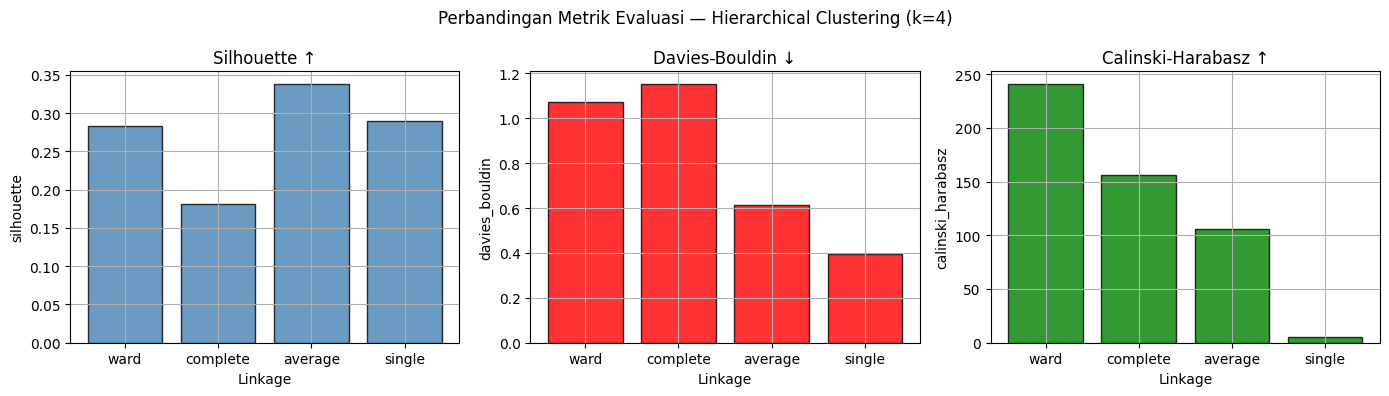

In [ ]:
# Bar chart perbandingan metrik antar linkage
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
titles  = ['Silhouette ↑', 'Davies-Bouldin ↓', 'Calinski-Harabasz ↑']
colors  = ['steelblue', 'red', 'green']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.bar(hier_eval['linkage'], hier_eval[metric], color=color, edgecolor='black', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Linkage')
    ax.set_ylabel(metric)

plt.suptitle('Perbandingan Metrik Evaluasi — Hierarchical Clustering (k=4)', fontsize=12)
plt.tight_layout()
plt.show()

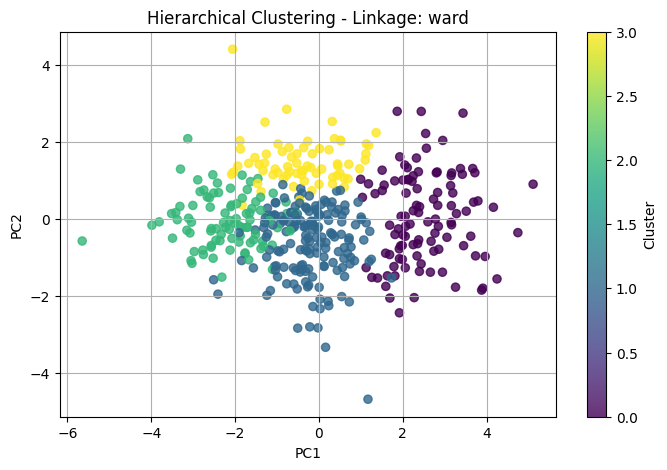

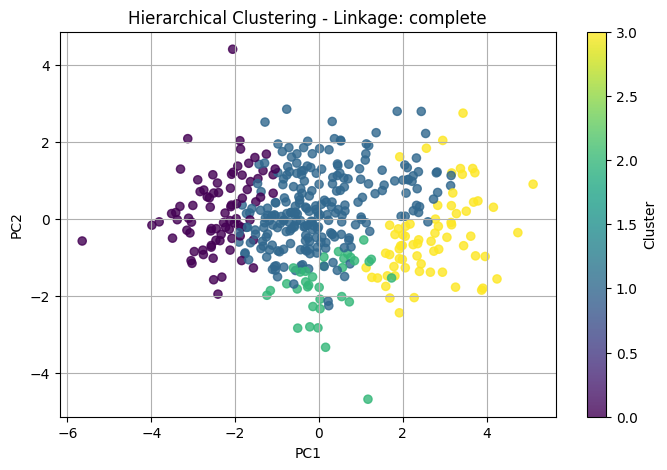

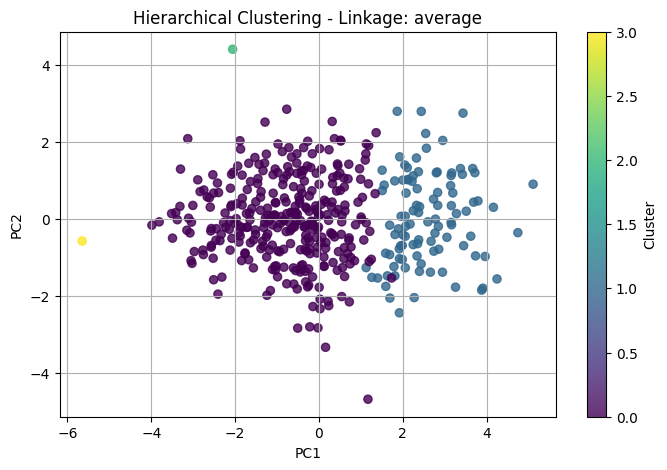

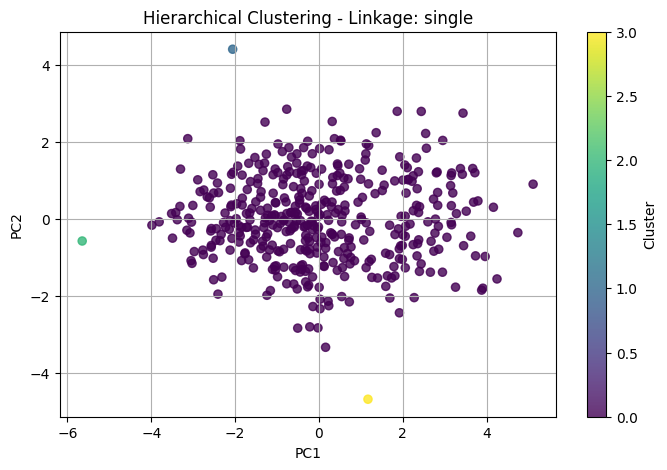

In [ ]:
for method in linkage_methods:
    plot_cluster_pca(df[f'cluster_hier_{method}'], f'Hierarchical Clustering - Linkage: {method}')

In [ ]:
# Profil hierarchical clustering dengan linkage Ward
profile_hier_ward = df.groupby('cluster_hier_ward')[feature_cols].mean()
profile_hier_ward

,fitur_1,fitur_2,fitur_3_korelasi,fitur_4_skala_besar,fitur_5_noise
cluster_hier_ward,,,,,
0,4.016275,3.355791,11.137602,140.430007,1.769392
1,1.185499,0.662684,3.469493,91.279430,0.695050
2,-1.794052,-0.189585,-5.021793,75.438801,-0.487255
3,-0.587379,2.597066,-1.710003,128.578709,-0.601494


### Tugas Mahasiswa 5 — Analisis Hierarchical Clustering
Jawab pertanyaan berikut:
1. Linkage mana yang memberikan hasil paling baik berdasarkan metrik evaluasi? Jelaskan.
2. Apakah linkage dengan skor terbaik juga menghasilkan visualisasi dan profil kluster yang paling mudah ditafsirkan?
3. Apa risiko menggunakan `single linkage` pada data dengan outlier atau data yang saling berdekatan?
4. Bandingkan hasil hierarchical clustering terbaik dengan K-Means utama.

1. **Ward** adalah linkage terbaik secara keseluruhan, meski tidak unggul di semua metrik sekaligus.

Berikut ringkasan metrik aktual:

| Linkage  | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ | Distribusi Kluster     |
|----------|-------------:|-----------------:|--------------------:|------------------------|
| ward     | 0.283        | 1.071            | **240.5**           | 104 / 162 / 90 / 68    |
| complete | 0.181        | 1.152            | 155.97              | 82 / 239 / 34 / 69     |
| average  | **0.338**    | **0.614**        | 106.1               | 322 / 100 / 1 / 1      |
| single   | 0.289        | 0.395            | 5.51                | **421 / 1 / 1 / 1**    |

Secara angka, *average* tampak unggul di Silhouette dan DB, dan *single* memiliki DB terendah. Namun kedua skor itu menyesatkan. Average membentuk distribusi 322/100/1/1 yang mana dua kluster berisi hanya 1 titik, sisa data mengumpul di satu kluster besar. Single bahkan lebih ekstrem: 421 dari 424 data masuk ke satu kluster, dan tiga kluster lain masing-masing hanya 1 titik. DB menjadi rendah bukan karena pemisahannya baik, melainkan karena kluster berisi 1 titik memiliki sebaran internal = 0, yang secara matematis menarik skor DB ke bawah secara artifisial.

Ward menghasilkan distribusi paling seimbang (104/162/90/68), CH tertinggi (240.5), yang berarti kluster benar-benar kompak dan terpisah jauh satu sama lain, serta tidak menunjukkan efek *chaining*. Ward adalah satu-satunya linkage yang menghasilkan 4 kluster yang bermakna dan dapat diinterpretasi, sehingga dipilih sebagai yang terbaik.

2. Tidak. Average memiliki skor Silhouette dan DB terbaik, tetapi cenderung membentuk kluster yang sangat tidak seimbang ukurannya (efek chaining), sehingga sulit diinterpretasi secara substantif. Ward menghasilkan kluster yang lebih kompak dan seimbang, sehingga lebih mudah ditafsirkan meskipun skornya tidak selalu tertinggi.

3. Risiko single linkage:
Single linkage rentan terhadap efek chaining, outlier dan titik-titik berdekatan ditarik berantai ke satu kluster besar, menghasilkan distribusi sangat tidak seimbang. Terbukti dari CH yang sangat rendah (5.51) dibanding metode lain, menandakan kluster hampir tidak terpisah secara struktural.

4. Perbandingan Hierarchical Ward vs K-Means k=4:
K-Means k=4 lebih unggul di CH (274.6 vs 240.5) dan DB (1.024 vs 1.071), dengan distribusi kluster yang lebih seimbang. Hierarchical Ward sedikit tertinggal di semua metrik, kemungkinan karena sensitivitasnya terhadap outlier yang memengaruhi proses penggabungan agglomeratif.

## 9. Perbandingan Akhir Model

Bandingkan model berdasarkan evaluasi numerik, visualisasi, distribusi ukuran kluster, dan kemudahan interpretasi.

In [ ]:
comparison = []

# K-Means utama
labels = df['cluster_kmeans_utama']
comparison.append({
    'model': f'KMeans_k{k_utama}',
    'silhouette': silhouette_score(X_scaled, labels),
    'davies_bouldin': davies_bouldin_score(X_scaled, labels),
    'calinski_harabasz': calinski_harabasz_score(X_scaled, labels),
    'cluster_size': dict(pd.Series(labels).value_counts().sort_index())
})

# K-Means pembanding
labels = df['cluster_kmeans_pembanding']
comparison.append({
    'model': f'KMeans_k{k_pembanding}',
    'silhouette': silhouette_score(X_scaled, labels),
    'davies_bouldin': davies_bouldin_score(X_scaled, labels),
    'calinski_harabasz': calinski_harabasz_score(X_scaled, labels),
    'cluster_size': dict(pd.Series(labels).value_counts().sort_index())
})

# Hierarchical methods
for method in linkage_methods:
    labels = df[f'cluster_hier_{method}']
    comparison.append({
        'model': f'Hierarchical_{method}_k{n_clusters_h}',
        'silhouette': silhouette_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels),
        'cluster_size': dict(pd.Series(labels).value_counts().sort_index())
    })

comparison_df = pd.DataFrame(comparison)
comparison_df

,model,silhouette,davies_bouldin,calinski_harabasz,cluster_size
0,KMeans_k4,0.307394,1.024268,274.602117,"{0: 114, 1: 93, 2: 106, 3: 111}"
1,KMeans_k3,0.285673,1.227793,272.283168,"{0: 186, 1: 106, 2: 132}"
2,Hierarchical_ward_k4,0.283423,1.070530,240.486602,"{0: 104, 1: 162, 2: 90, 3: 68}"
3,Hierarchical_complete_k4,0.180811,1.151531,155.967577,"{0: 82, 1: 239, 2: 34, 3: 69}"
4,Hierarchical_average_k4,0.337587,0.614026,106.128888,"{0: 322, 1: 100, 2: 1, 3: 1}"
5,Hierarchical_single_k4,0.289182,0.395041,5.508532,"{0: 421, 1: 1, 2: 1, 3: 1}"


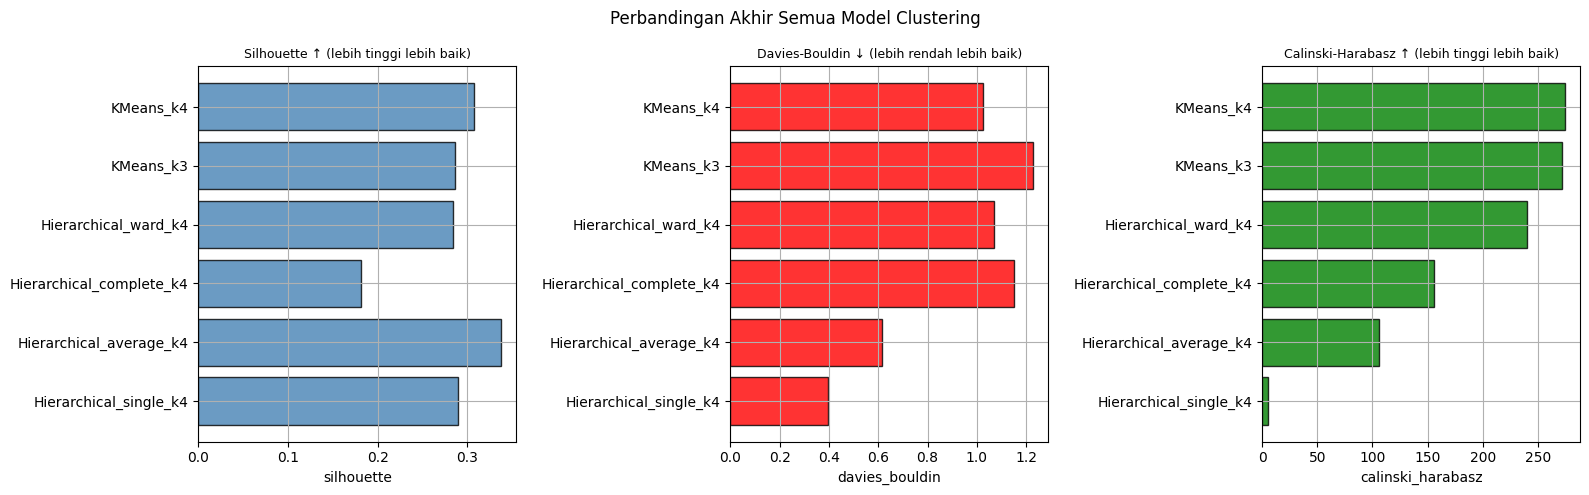

In [ ]:
# Visualisasi perbandingan akhir semua model
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
titles  = ['Silhouette ↑ (lebih tinggi lebih baik)',
           'Davies-Bouldin ↓ (lebih rendah lebih baik)',
           'Calinski-Harabasz ↑ (lebih tinggi lebih baik)']
colors  = ['steelblue', 'red', 'green']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.barh(comparison_df['model'], comparison_df[metric],
            color=color, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(metric)
    ax.invert_yaxis()

plt.suptitle('Perbandingan Akhir Semua Model Clustering', fontsize=12)
plt.tight_layout()
plt.show()

### Tugas Mahasiswa 6 — Kesimpulan Akhir
Tuliskan kesimpulan akhir dalam 3–5 paragraf yang mencakup:
1. Model dan jumlah kluster yang Anda pilih sebagai solusi utama.
2. Alasan pemilihan berdasarkan metrik evaluasi, visualisasi, dan interpretasi profil kluster.
3. Tantangan utama yang muncul dalam proses clustering pada dataset ini.
4. Keterbatasan analisis Anda.
5. Rekomendasi analisis lanjutan jika dataset ini berasal dari kasus nyata, misalnya segmentasi pelanggan, segmentasi wilayah, atau segmentasi risiko.


Model yang dipilih adalah K-Means dengan k=4 sebagai solusi utama. Model ini menghasilkan silhouette = 0.307, Davies-Bouldin = 1.024, dan Calinski-Harabasz = 274.6, konsisten di posisi terbaik atau kedua terbaik di seluruh metrik evaluasi. Dibanding k=3 yang merupakan pembanding, k=4 menghasilkan profil kluster yang lebih granular dan dapat dibedakan: terdapat kelompok bernilai rendah, sedang, menengah-atas, dan tinggi yang masing-masing memiliki karakteristik fitur berbeda.

Alasan pemilihan tidak hanya bertumpu pada skor numerik. Secara metrik murni, k=2 unggul di Silhouette (0.378) dan CH (325.9), namun terlalu kasar untuk memberikan wawasan substantif. K=4 dipilih karena sesuai dengan struktur bawaan dataset (4 pusat generatif), menghasilkan distribusi kluster yang seimbang (93–114 data per kluster), dan setiap kluster memiliki profil fitur yang dapat dibedakan dan diinterpretasi. Visualisasi PCA juga menunjukkan pemisahan yang cukup baik pada k=4 meski tidak sempurna akibat proyeksi dimensi.

Tantangan utama dalam proses ini adalah ambiguitas jumlah kluster yang optimal, tidak ada satu metrik pun yang memberikan jawaban tunggal. Selain itu, keberadaan fitur berkorelasi tinggi (f1-f3, f2-f4) dan perbedaan skala yang ekstrem pada fitur_4_skala_besar mempersulit interpretasi kluster di ruang fitur asli, meskipun standardisasi telah dilakukan. Outlier juga berpengaruh pada stabilitas centroid K-Means.

Keterbatasan analisis meliputi: (1) sampling dalam dendrogram (120 dari 424 data) berisiko tidak merepresentasikan seluruh struktur; (2) evaluasi hanya berbasis metrik internal yang tidak mengukur relevansi bisnis/domain; (3) K-Means sensitif terhadap inisialisasi meski sudah diatasi dengan n_init=20; (4) PCA sebagai visualisasi kehilangan sebagian informasi dari dimensi yang tidak tertangkap PC1 dan PC2.

Rekomendasi lanjutan jika dataset berasal dari kasus nyata (misal segmentasi pelanggan): pertama, lakukan analisis PCA lebih dalam untuk mereduksi fitur redundan sebelum clustering. Kedua, validasi kluster secara domain dengan melibatkan pakar bisnis untuk memastikan setiap segmen bermakna dan dapat ditindaklanjuti. Ketiga, eksplorasi algoritma clustering yang lebih robust terhadap outlier seperti DBSCAN atau k-Medoids. Keempat, lakukan profiling kluster secara longitudinal untuk memahami stabilitas segmen dari waktu ke waktu.

## 10. Pertanyaan Reflektif Konseptual
Jawab secara ringkas tetapi argumentatif.

1. Mengapa clustering tidak dapat dievaluasi dengan akurasi seperti supervised learning?
2. Mengapa nilai silhouette yang tinggi belum tentu menjamin kluster bermakna secara bisnis atau domain?
3. Dalam kondisi apa K-Means kurang sesuai digunakan?
4. Dalam kondisi apa hierarchical clustering lebih informatif dibanding K-Means?
5. Jelaskan mengapa preprocessing dapat mengubah hasil clustering secara signifikan.


1. Akurasi mengukur kecocokan prediksi dengan label ground truth yang telah diketahui. Clustering bersifat unsupervised, tidak ada label referensi. Evaluasi dilakukan dengan metrik internal (kohesi dalam kluster, separasi antar kluster) yang mengukur kualitas struktur geometris, bukan kebenaran terhadap suatu standar eksternal.

2. Silhouette hanya mengukur separasi geometris di ruang fitur. Fitur yang digunakan mungkin tidak relevan secara domain, atau granularitas kluster tidak sesuai kebutuhan (misal: k=2 menghasilkan silhouette tertinggi tetapi terlalu kasar untuk segmentasi pelanggan yang membutuhkan 5 profil berbeda). Makna kluster ditentukan oleh relevansi domain, bukan angka metrik semata.

3. Kondisi K-Means yang kurang sesuai:

*   Kluster berbentuk non-spherical (elongated, concave, atau ring)
*   ukuran kluster sangat tidak seimbang
*   data mengandung banyak outlier yang menarik centroid
*    jumlah kluster tidak diketahui dan sulit diestimasi dari data

4. Kondisi hierarchical lebih informatif:

*   Jumlah kluster belum diketahui, dendrogram memberikan gambaran hierarki lengkap tanpa harus menentukan k di awal
*   hubungan hierarkis antar kluster penting secara domain (taksonomi, filogenetik, segmentasi berjenjang)
*   dataset berukuran kecil-menengah di mana komputasi masih efisien
*   ingin mengeksplorasi berbagai granularitas tanpa menjalankan ulang model

5. Clustering berbasis jarak Euclidean, fitur dengan skala besar secara otomatis mendominasi perhitungan jarak, seolah-olah fitur lain tidak relevan. Standardisasi menyamakan kontribusi setiap fitur. Hasilnya, bentuk, posisi, dan bahkan jumlah kluster yang "optimal" bisa berubah drastis: sebelum scaling, kluster mungkin hanya mencerminkan perbedaan fitur_4. setelah scaling, seluruh fitur berkontribusi seimbang dalam pembentukan kluster.



